In [ ]:
# Add Import required libraries for your solution
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import pytesseract
from pytesseract import Output

In [ ]:
!pip install pytesseract

In [ ]:
#  Load Your Model
# --------------------------------------------------------------
# In this section, load your pre-trained model.
#
# Option 1: Load a model from Hugging Face Hub
# Ensure the model repository is public or that you have the required access token.
# MODEL_NAME = "username/model_name"
# model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
#
# Important: If using Hugging Face, ensure that:
# - The model repository is set to "public" or you have an authentication token.
# - The model link is accessible and does not require special permissions.
#
# Option 2: Load model weights from a local or cloud storage (e.g., Google Drive)
# If using PyTorch, ensure the model architecture is defined before loading weights.
# weights_path = "https://drive.google.com/uc?id=YOUR_FILE_ID"
#
# Ensure the Google Drive link is publicly accessible (Anyone with the link can view).

# Load the weights into the model (example in pytorch ):
# model.load_state_dict(torch.load("model.pth", map_location=torch.device('cpu')))
# model.eval()  # Set the model to evaluation mode


In [ ]:
def adap_thresh(image, size=21, c=16):
  size = 21
  c = size - 5
  return cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, size, c)
def remove_shadow(img):
  im = cv2.dilate(img, np.ones((3, 3), dtype=np.uint8), iterations=1)
  im = cv2.erode(im, np.ones((3, 3), dtype=np.uint8), iterations=1)
  return cv2.medianBlur(im, 3)


def merge_rectangles(boxes, threshold=0.5):
  x0, y0, w0, h0 = cv2.boundingRect(boxes[0])
  merged = [(x0, y0, w0, h0)]
  for box in boxes:
        x, y, w, h = cv2.boundingRect(box)
        if x0+w<=x or x-x0 <= w0*threshold:
            merged[-1] = (min(x0, x), min(y0, y), max(x0+w0+w, x+w)-min(x0, x), max(y0+h0, y+h)-min(y0, y))
            merged.append((x, y, w, h))
        else:
            merged.append((x, y, w, h))
        x0, y0, w0, h0 = x, y, w, h
  return merged

def get_bounding(thresh_image, original):
  # report = []
  # ROI_number = 0
  cnts = cv2.findContours( thresh_image , cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
  cnts = cnts[0] if len(cnts) == 2 else cnts[1]
  cnts=sorted(cnts, key=lambda x: (cv2.boundingRect(x)[1], cv2.boundingRect(x)[0]))
  # cnts = merge_rectangles(cnts)
  ROI = []
  for c in cnts:
      x,y,w,h = cv2.boundingRect(c)
      if w<original.shape[0]/2 and h<original.shape[1]/2:
          cv2.rectangle(original, (x, y), (x + w, y + h), (36,255,12), 3)
          ROI.append(thresh_image[y:y + h, x:x + w])
  return original, ROI
def is_arabic(text):
    return any("\u0600" <= char <= "\u06FF" for char in text)

#give an image with tesseract result
def tesser_OCR_result(img, data):
  im = img.copy()
  #get coordinates for the words
  for i in range(0, len(data['text'])):
    #set confidence threshold for accepted words
    if data['conf'][i] < 60: continue

    #get the text and its boundaries
    x = data['left'][i]
    y = data['top'][i]
    w = data['width'][i]
    h = data['height'][i]
    text = data['text'][i]

    #draw the boundaries
    cv2.rectangle(im, (x, y), (x+w, y+h), (0, 0, 255), 2)

    #add arabic text
    if is_arabic(text):
      print(text)
      # reshaped_text = arabic_reshaper.reshape(text)  # Fix isolated letters
      # text = get_display(reshaped_text)  # Convert to right-to-left
    cv2.putText(im, text, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 2, cv2.LINE_AA)
  plt.figure(figsize=(10, 10))
  plt.imshow(im, cmap = 'gray')
  plt.show()

In [ ]:
# Submit Function
# --------------------------------------------------------------
# This function takes a list of image paths as input and returns the extracted
# prescription text associated with each image.
#
# Args:
# images (list of str): List of paths to input images.
#
# Returns:
# list of str: Extracted prescription texts corresponding to each input image.
# --------------------------------------------------------------

def submit(images):
    """
    Processes a list of prescription images and extracts the associated text.

    Args:
        images (list of str): List of file paths to input prescription images.

    Returns:
        list of str: Extracted prescription texts corresponding to each input image.
    """

    extracted_texts = []
    for image_path in images:
        # Load and preprocess the image

        # Perform model inference
        image = cv2.imread(image_path)
        image = cv2.resize(image, None, fx =.4 , fy = .4, interpolation = cv2.INTER_CUBIC)
        img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        #%%
        thresh = adap_thresh(img)
        refined_image = remove_shadow(thresh)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        inv = cv2.bitwise_not(refined_image)
        dilated = cv2.dilate(inv, kernel, iterations=5)
        normal = cv2.bitwise_not(dilated)
        original, ROI = get_bounding(normal, image)
        #%%
        output = cv2.resize(original, None, fx =.4 , fy = .4, interpolation = cv2.INTER_CUBIC)
        custom_config = r'--oem 3 --psm 1 -c load_system_dawg=0 -c load_freq_dawg=0 -l ara+eng'
        text = pytesseract.image_to_data(output, config=custom_config, output_type=Output.DICT)

        arr = []
        for t in text['text']:
            print(t)
            if t not in ['', ' ', '\n']:
                arr.append(t)

        extracted_texts.append(arr)

    return extracted_texts


In [ ]:
image=cv2.imread("Beauty_prescription_6.jpg")

In [ ]:
# Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

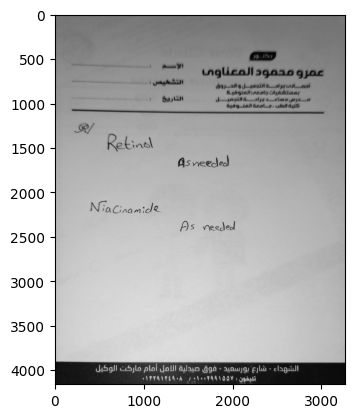

In [ ]:
plt.imshow(gray_image,cmap='gray')

In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
imgAdap_thresh=adap_thresh(gray_image)
dilted=cv2.dilate(imgAdap_thresh, kernel, iterations=5)
PreprocessedImg=get_bounding(imgAdap_thresh,image)


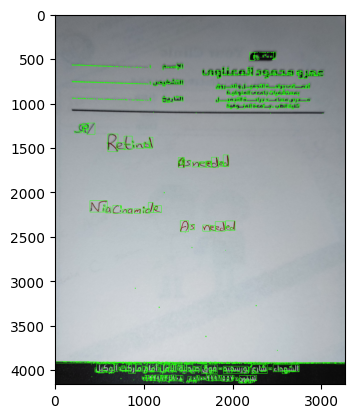

In [ ]:
plt.imshow(PreprocessedImg[0],cmap='gray')

In [ ]:
len(PreprocessedImg)

2

In [ ]:
PreprocessedImg[0][:5]

array([[[110, 114, 119],
        [111, 115, 120],
        [110, 114, 119],
        ...,
        [116, 116, 122],
        [116, 116, 122],
        [116, 116, 122]],

       [[109, 113, 118],
        [109, 113, 118],
        [109, 113, 118],
        ...,
        [116, 116, 122],
        [116, 116, 122],
        [116, 116, 122]],

       [[108, 112, 117],
        [109, 113, 118],
        [109, 113, 118],
        ...,
        [116, 116, 122],
        [116, 116, 122],
        [116, 116, 122]],

       [[109, 113, 118],
        [109, 113, 118],
        [109, 113, 118],
        ...,
        [116, 116, 122],
        [116, 116, 122],
        [116, 116, 122]],

       [[109, 113, 118],
        [109, 113, 118],
        [109, 113, 118],
        ...,
        [116, 116, 122],
        [116, 116, 122],
        [116, 116, 122]]], dtype=uint8)

In [ ]:
PreprocessedImg[1]

[array([[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255,   0,   0, ..., 255, 255, 255],
        [255, 255,   0, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]], dtype=uint8),
 array([[255, 255, 255, 255, 255, 255, 255, 255],
        [255, 255, 255,   0,   0,   0,   0, 255],
        [255,   0,   0,   0,   0,   0, 255, 255],
        [255, 255, 255, 255, 255, 255, 255, 255]], dtype=uint8),
 array([[255, 255, 255, 255, 255],
        [255,   0, 255, 255, 255],
        [255,   0,   0,   0, 255],
        [255, 255, 255, 255, 255]], dtype=uint8),
 array([[255, 255, 255, 255, 255, 255],
        [255, 255, 255,   0, 255, 255],
        [255,   0,   0,   0,   0, 255],
        [255,   0,   0,   0,   0, 255],
        [255,   0,   0,   0,   0, 255],
        [255, 255, 255, 255, 255, 255]], dtype=uint8),
 array([[255, 255, 255, 255, 255],
        [255, 255,   0,   0, 255],
       

In [ ]:
PreprocessedImg[0][0]

array([[110, 114, 119],
       [111, 115, 120],
       [110, 114, 119],
       ...,
       [116, 116, 122],
       [116, 116, 122],
       [116, 116, 122]], dtype=uint8)

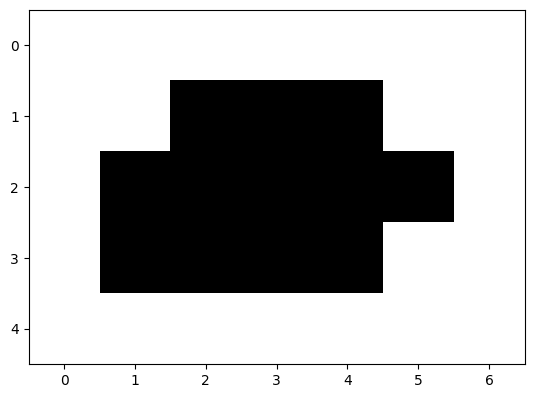

In [ ]:
counter=0
for img in PreprocessedImg[1]:
    if(counter>10):
      break
    counter+=1

    plt.imshow(img,cmap='gray')

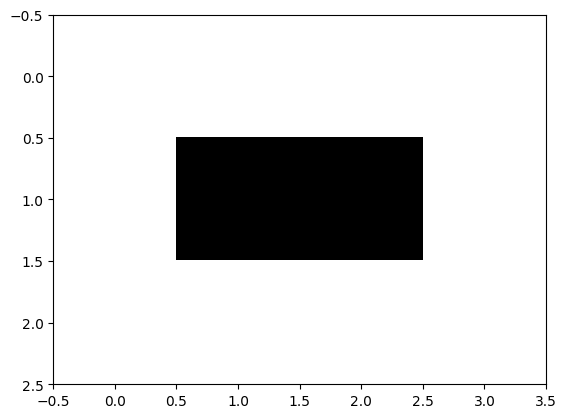

In [ ]:
plt.imshow(PreprocessedImg[1][1500],cmap='gray')

In [ ]:
import numpy as np
import pandas as pd
#from keras.preprocessing.image import ImageDataGenerator
import os
import random
import cv2
import random
import matplotlib.pyplot as plt
import imutils
import tensorflow as tf
from sklearn.preprocessing import LabelBinarizer

#from google.colab.patches import cv2_imshow

In [ ]:
# Initialize a LabelBinarizer object
LB = LabelBinarizer()

  # Fit LabelBinarizer to data
labels = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S',
              'T','U','V','W','X','Y','Z','a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i',
              'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x',
              'y', 'z']  # Replace with your actual class labels

LB.fit(labels)

LabelBinarizer()

In [ ]:
def sort_contours(cnts, method="left-to-right"):
    # Initialize the reverse flag to False
    reverse = False
    # Initialize the dimension index to 0 (x coordinate)
    i = 0

    # If sorting in right-to-left or bottom-to-top, set reverse to True
    if method in ["right-to-left", "bottom-to-top"]:
        reverse = True

    # If sorting by vertical position (top-to-bottom or bottom-to-top), use the y coordinate
    if method in ["top-to-bottom", "bottom-to-top"]:
        i = 1

    # Compute the bounding boxes for each contour
    boundingBoxes = [cv2.boundingRect(c) for c in cnts]

    # Sort the contours and bounding boxes by the specified dimension and direction
    (cnts, boundingBoxes) = zip(*sorted(zip(cnts, boundingBoxes),
                                        key=lambda b: b[1][i], reverse=reverse))

    # Return the sorted contours and their bounding boxes
    return (cnts, boundingBoxes)

In [ ]:

def get_letters(image):
    """
    Function to detect and recognize letters in an image.

    Parameters:
    img (str): Path to the input image file.

    Returns:
    letters (list): List containing the recognized letters.
    image (numpy.ndarray): Image with bounding boxes drawn around detected letters.
    """
    letters = []  # List to store information about detected letters

    gray=image
    ret, thresh1 = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)  # Apply thresholding to create a binary image
    dilated = cv2.dilate(thresh1, None, iterations=2)  # Dilate the binary image

    cnts = cv2.findContours(dilated.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)  # Find contours in the binary image
    cnts = imutils.grab_contours(cnts)
    cnts = sort_contours(cnts, method="left-to-right")[0]  # Sort contours from left to right

    # Load the trained model
    model_path = "handwritten_model.keras"
    model = tf.keras.models.load_model(model_path)

    # Loop over the contours
    for c in cnts:
        if cv2.contourArea(c) > 1:
            (x, y, w, h) = cv2.boundingRect(c)
            print("y equal",y)
            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Draw bounding box around detected letter
        roi = gray[y:y + h, x:x + w]  # Extract region of interest (ROI) containing the letter
        thresh = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]  # Apply thresholding to the ROI
        thresh = cv2.resize(thresh, (32, 32), interpolation=cv2.INTER_CUBIC)  # Resize the ROI to 32x32 pixels
        thresh = thresh.astype("float32") / 255.0  # Normalize the pixel values
        thresh = np.expand_dims(thresh, axis=-1)  # Add an extra dimension to represent batch size
        thresh = thresh.reshape(1, 32, 32, 1)  # Reshape the array to match model input shape
        ypred = model.predict(thresh)  # Predict the letter using the model
        ypred = LB.inverse_transform(ypred)  # Inverse transform the predicted label
        [p] = ypred
        letters.append(p)  # Append the recognized letter to the list

    return letters, image


In [ ]:
def get_word(letter):
    word = "".join(letter)
    return word

In [ ]:
# image_path = os.path.join(handwritting_test_dir, 'TEST_9716.jpg')
# letter,image = get_letters(image_path)

# word = get_word(letter)
# print('\nHandritting Recognition Model\n')
# plt.imshow(image)
# print(f"The word written on the image is : {word}")

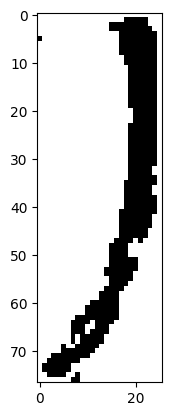

In [ ]:
plt.imshow(PreprocessedImg[1][0],cmap='gray')

[[  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ... 255 255   0]
 ...
 [  0   0   0 ... 255 255   0]
 [  0   0   0 ... 255 255   0]
 [  0   0   0 ...   0   0   0]]
y equal 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step

Handritting Recognition Model

The word written on the image is : D
[[  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 255   0]
 [  0   0   0   0   0   0   0   0]]
y equal 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step

Handritting Recognition Model

The word written on the image is : I
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
y equal 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step

Handritting Recognition Model

The word written on the image is : R
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
y equal 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step

Handritting Recognition Model

The word written on the image is : R
[[  0   0   0   0   0]
 [  0   0   0   0   0]
 [  0

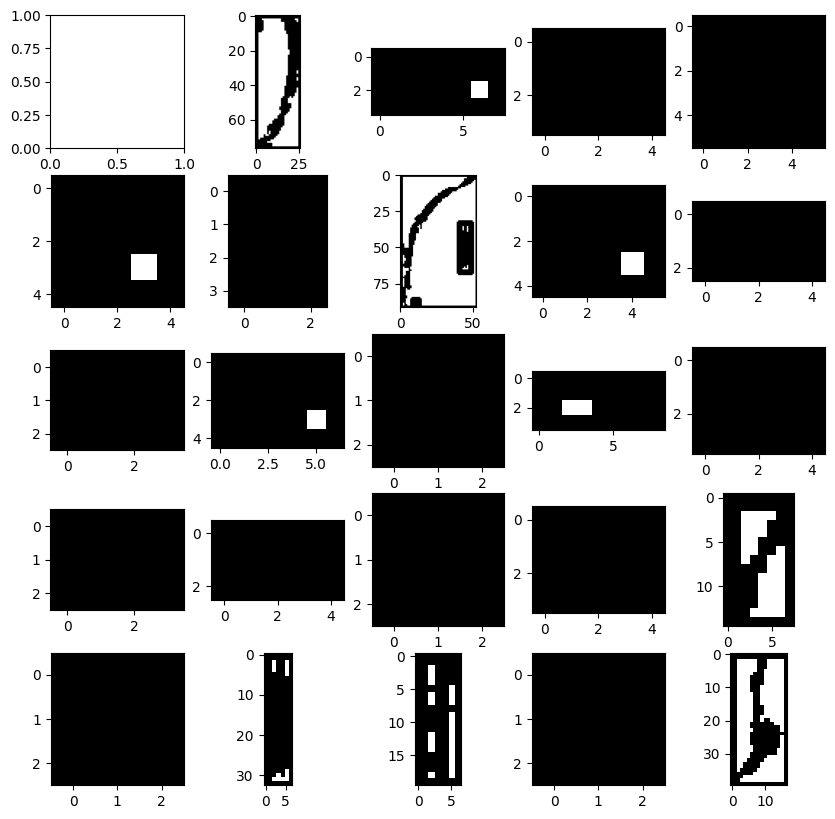

In [ ]:
counter=1
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(10, 10))
i,j=0,0
for img in PreprocessedImg[1]:
    if(counter>24):
      break
    counter+=1



    print(img)
    letter,image = get_letters(img)
    word = get_word(letter)
    print('\nHandritting Recognition Model\n')
    j+=1
    if(j==5):
      j=0
      i+=1


    axes[i,j].imshow(image,cmap='gray')
    print(f"The word written on the image is : {word}")


In [ ]:

letter,image = get_letters(PreprocessedImg[1][0])

UnboundLocalError: cannot access local variable 'y' where it is not associated with a value


Handritting Recognition Model

The word written on the image is : MLRRRRTRRRRRIRITIRQRRRRRIRRRITRRTIRRRRRWIIRRRRIRIRRRRICCIJITQIIBTRIRTRRRRRRRRRICRRIRRRTPIRTRRFRRRRRRJRIIARRTRRRRRITRRLRALLRTRRTMRIRRRRMRRRARRRIRIRRIRAKRRCRFRDRRTFRRIRRDTLTRRDERRRIRRWWRRRRRRRRRRWRRIRTARARRRRSRTRRWRRERRWRJWERDRRDRWTRRRRTRRRRRRRRRRTRWWMRRRWRTRRRRRIRRRIRIRRRRRRRRRRTTRRIRRRRRRIRRRRRRRRRRRIRRRRRRRTRRTRRTRIERRRRIIIRRRARRRRTRTRRRRAR


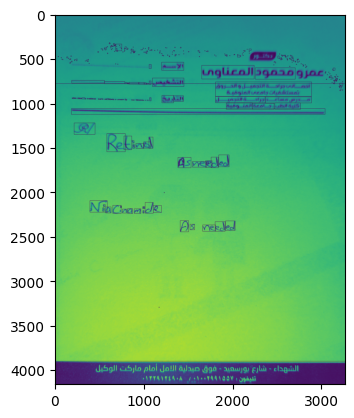

In [ ]:
word = get_word(letter)
print('\nHandritting Recognition Model\n')
plt.imshow(image)
print(f"The word written on the image is : {word}")